<a href="https://colab.research.google.com/github/irajamuller/error_corrections/blob/main/UA3_UA4_Transversalidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit_aer pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.9 MB/s eta 0:00:00


In [2]:
# Classes do qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator, Aer
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, array_to_latex

import numpy as np

In [76]:
def create_repetition_code_bitflip():
  q_codes = QuantumRegister(3, 'code')
  q_ancilla = QuantumRegister(2, 'ancilla')
  c_syndromes = ClassicalRegister(2, name='syndrome')
  logical_bit = ClassicalRegister(1, 'logical bit')

  qc = QuantumCircuit(q_codes, q_ancilla, c_syndromes, logical_bit)
  qc.barrier()

  # Encoding
  qc.cx(0, 1)
  qc.cx(0, 2)
  qc.barrier()

  # Error inject
  qc.x(0)
  qc.barrier()

  # Syndrome
  qc.cx(0, 3); qc.cx(1, 3)
  qc.cx(1, 4); qc.cx(2, 4)
  qc.barrier()

  qc.measure(3, 0); qc.measure(4, 1)
  qc.barrier()

  # ==========================================
  # Correção
  # Síndrome '01' Erro no Qubit 0
  # Síndrome '11' Erro no Qubit 1
  # Síndrome '10' Erro no Qubit 2
  # ==========================================
  with qc.if_test((c_syndromes, 0b01)): qc.x(0)

  with qc.if_test((c_syndromes, 0b11)): qc.x(1)

  with qc.if_test((c_syndromes, 0b10)): qc.x(2)
  qc.barrier()

  # Decoding
  qc.cx(0, 1); qc.cx(0, 2)

  # Mede o qubit corrigido no bit clássico 2
  qc.measure(0, 2)

  backend = AerSimulator()
  result = backend.run(transpile(qc), shots=1024).result()
  counts = result.get_counts()

  return qc, counts

def create_repetition_code_transversal():
    q_codes = QuantumRegister(3, 'code')
    c_outcomes = ClassicalRegister(3, 'outcomes')
    qc = QuantumCircuit(q_codes, c_outcomes)

    # Encode inicial lógico |0_L> = |000>
    qc.cx(q_codes[0], q_codes[1])
    qc.cx(q_codes[0], q_codes[2])
    qc.barrier()

    # Injection error
    qc.x(q_codes[0])
    qc.barrier()

    # Aplicação de Porta Clifford Transversal (Exemplo: Porta X lógica)
    #
    for qubit in q_codes:
        qc.x(qubit)
    qc.barrier()

    # Medição Transversal (Leitura dos qubits físicos)
    qc.measure(q_codes, c_outcomes)

    backend = AerSimulator()
    result = backend.run(transpile(qc), shots=1024).result()
    counts = result.get_counts()

    print(counts)
    # Voto majoritário
    contagens_logicas = {}

    for bitstring, frequencia in counts.items():
        qtd_uns = bitstring.count('1')
        qtd_zeros = bitstring.count('0')

        bit_logico = '1' if qtd_uns > qtd_zeros else '0'

        contagens_logicas[bit_logico] = contagens_logicas.get(bit_logico, 0) + frequencia

    return qc, contagens_logicas

In [77]:
qc, counts = create_repetition_code_bitflip()
qc_transversal, counts_transversal = create_repetition_code_transversal()

{'110': 1024}


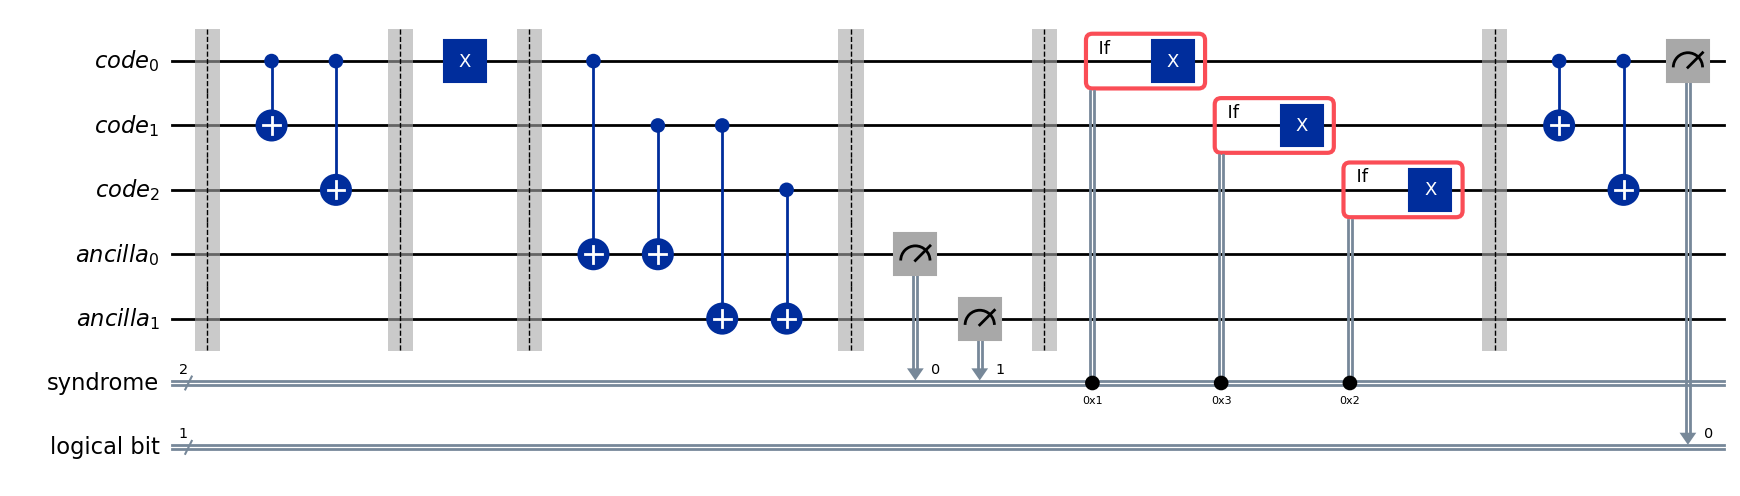

In [71]:
qc.draw('mpl')

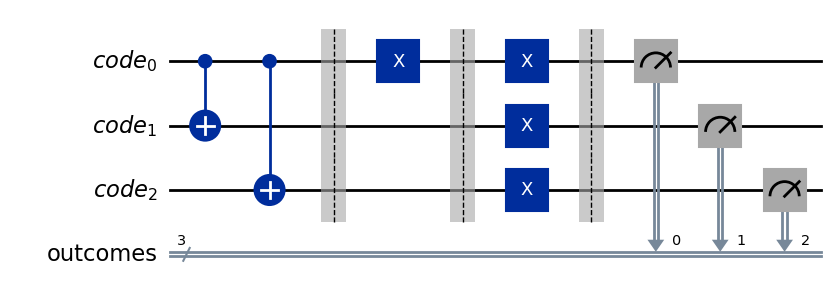

In [72]:
qc_transversal.draw('mpl')

In [73]:
print(counts)
print(counts_transversal)

{'0 01': 1024}
{'1': 1024}


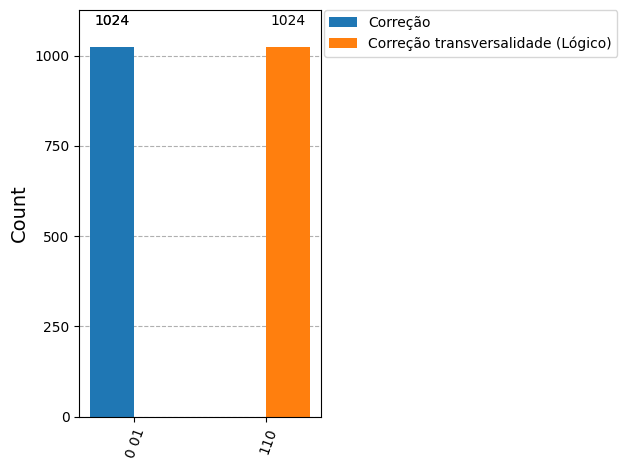

In [61]:
plot_histogram(
    [counts, counts_transversal],
    legend=['Correção', 'Correção transversalidade (Lógico)']
)